In [2]:
import glob,os
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [16]:
dfall = pd.read_csv("all_neurons_sholl.csv",index_col=0)

In [3]:
dfc = pd.read_excel(r"bla_soma_type.xlsx",index_col=0)

In [19]:
dfc["type"] = dfc["type"].astype("str")

In [20]:
dfc["cluster"] = dfc["geno"]+"_"+dfc["type"]

In [21]:
dfall = pd.concat([dfc["cluster"],dfall],axis=1)

In [22]:
dfall2 = dfall.loc[dfall.index.str.contains("Sst")]

In [23]:
dfall2["cluster"] = dfall2["cluster"].str.replace("Sst_1","Sst_long")
dfall2["cluster"] = dfall2["cluster"].str.replace("Sst_2","Sst_local")
dfall2["cluster"] = dfall2["cluster"].str.replace("Sst_3","Sst_local")


C:\Users\zljia\AppData\Local\Temp\ipykernel_27404\473157019.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfall2["cluster"] = dfall2["cluster"].str.replace("Sst_1","Sst_long")
C:\Users\zljia\AppData\Local\Temp\ipykernel_27404\473157019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfall2["cluster"] = dfall2["cluster"].str.replace("Sst_2","Sst_local")
C:\Users\zljia\AppData\Local\Temp\ipykernel_27404\473157019.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

In [24]:
dfall2.to_csv("Sst_neurons_sholl.csv")

In [25]:
dfall= pd.read_csv("Sst_neurons_sholl.csv")
dfall["0.0"] = 0


In [28]:
dfall.cluster.value_counts()

cluster
Sst_local    11
Sst_long      7
Name: count, dtype: int64

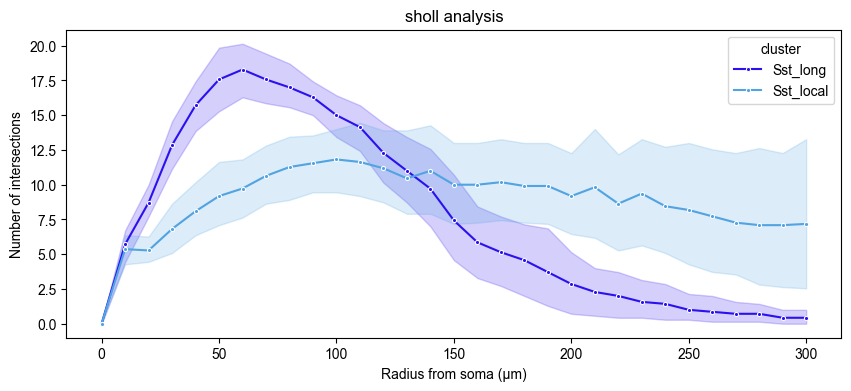

In [27]:
df_long = dfall.melt(
    id_vars=['Unnamed: 0', 'cluster'],  # 保留 sample 和 cluster
    var_name='x',                  # 原来的 10,20,30 → x
    value_name='value'             # 数值
)
df_long["x"] = pd.to_numeric(df_long["x"])
df_long2 = df_long.loc[df_long.x<=300]
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.rc("font",family="Arial")

plt.figure(figsize=(10,4))

dic_list = {"Sst_long":"#2B11EF","Sst_local":"#51a3e1"}

sns.lineplot(
    data=df_long2,
    x='x',          # 横轴
    y='value',      # 纵轴
    hue='cluster',  # 按 cluster 分组
    marker='.',
    palette = dic_list
)

plt.ylabel("Number of intersections")
plt.xlabel("Radius from soma (µm)")
plt.title('sholl analysis')
plt.savefig("sholl analysis_Sst.pdf",dpi=300)
plt.savefig("sholl analysis_Sst.jpg",dpi=300)